In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read files train & test
df_train = pd.read_csv(r'data/raw/raw_null_train.csv')
df_test = pd.read_csv(r'data/raw/raw_null_test.csv')

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23838 entries, 0 to 23837
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SEQN                      23838 non-null  float64
 1   Gender                    23838 non-null  float64
 2   Age                       23838 non-null  float64
 3   Race                      23838 non-null  float64
 4   PIR                       22035 non-null  float64
 5   Weight                    23462 non-null  float64
 6   Height                    23490 non-null  float64
 7   BMI                       23376 non-null  float64
 8   WaistCircumference        22722 non-null  float64
 9   Hba1c                     22517 non-null  float64
 10  FastingGlucose            22439 non-null  float64
 11  Albumin                   22171 non-null  float64
 12  ALT                       22143 non-null  float64
 13  AST                       22140 non-null  float64
 14  Alkali

In [4]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6227 entries, 0 to 6226
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SEQN                      6227 non-null   float64
 1   Gender                    6227 non-null   float64
 2   Age                       6227 non-null   float64
 3   Race                      6227 non-null   float64
 4   PIR                       5489 non-null   float64
 5   Weight                    6141 non-null   float64
 6   Height                    6145 non-null   float64
 7   BMI                       6135 non-null   float64
 8   WaistCircumference        5878 non-null   float64
 9   Hba1c                     5880 non-null   float64
 10  FastingGlucose            5863 non-null   float64
 11  Albumin                   5782 non-null   float64
 12  ALT                       5780 non-null   float64
 13  AST                       5772 non-null   float64
 14  Alkaline

### 1. Load data to pre-processing

In [24]:
df = df_train.copy()

### 2. Handle Noise Data

In [25]:
# Check wrong data that has value out of range - Laboratory measures
# Take Note: 100000 presentation +oo because document does not specify the upper limit
measure_range_laboratory = {
    "Hba1c":{
        "min": 3.1,
        "max": 19.5
    },
    "FastingGlucose": {
        "min": 2,
        "max": 728,
    },
    "Albumin": {
        "min": 0.3,
        "max": 50,
    },
    "ALT": {
        "min": 3,
        "max": 7000,
    },
    "AST": {
        "min": 3,
        "max": 7000,
    },
    "AlkalinePhosphotase": {
        "min": 2,
        "max": 6000,
    },
    "BUN": {
        "min": 2,
        "max": 336,
    },
    "GGT": {
        "min": 3,
        "max": 13200,
    },
    "TotalBilirubin": {
        "min": 0.1,
        "max": 175.5,
    },
    "UricAcid": {
        "min": 0.2,
        "max": 62.5,
    },
    "Creatinine": {
        "min": 0.10,
        "max": 122.04,
    },
    "TotalCholesterol": {
        "min": 0.3,
        "max": 258.06,
    },
    "HDLCholesterol": {
        "min": 0.103,
        "max": 5.8,
    },
    "Triglycerides": {
        "min": 0,
        "max": 100000,
    },
    "LDLCholesterol": {
        "min": 0,
        "max": 100000,
    },
    "Hemoglobin": {
        "min": 0,
        "max": 25,
    },
    "Hematocrit": {
        "min": 0,
        "max": 100000,
    },
    "MeanCellVolumn": {
        "min": 50,
        "max": 150,
    },
    "MeanCellHemoglobin": {
        "min": 0,
        "max": 100000,
    },
    "RedCellDistributionWidth": {
        "min": 0,
        "max": 100000,
    },
    "PlateletCount": {
        "min": 0,
        "max": 999,
    },
    "MeanPlateletVolume": {
        "min": 5,
        "max": 20,
    }
}

In [26]:
# Drop noise value
'''
   Strategy to drop noise data:
    1. Use boxplot to visualize outliers & noise
    2. Use Z-score to detect outliers & noise
      2.1 If Top value range equal 100000 => only check Z-score > 3
      2.2 Else if value out of range min && max => Noise
    3. Measure Consistency ratio
'''
          
def drop_noise_value(df_check):
    df_dq = df_check.copy()
    for col in df_dq.columns:
        if col in measure_range_laboratory.keys():
            print('len before remove outlier in {}: {}'.format(col, len(df_dq)))
            # Calculate Z-score of column
            z_score = (df_dq[col] - df_dq[col].mean()) / df_dq[col].std()
            max_value = measure_range_laboratory[col].get("max")
            min_value = measure_range_laboratory[col].get("min")
            if max_value >= 100000:
                df_dq = df_dq[~((z_score.abs() > 3) & (pd.notna(df_dq[col])))]
            else:
                df_dq = df_dq[~(((df_dq[col] < min_value) | (df_dq[col] > max_value)) & (pd.notna(df_dq[col])))]
            print('len after remove outlier in {}: {}'.format(col, len(df_dq)))
    return df_dq

In [27]:
df = drop_noise_value(df)

len before remove outlier in Hba1c: 23838
len after remove outlier in Hba1c: 23838
len before remove outlier in FastingGlucose: 23838
len after remove outlier in FastingGlucose: 23838
len before remove outlier in Albumin: 23838
len after remove outlier in Albumin: 23838
len before remove outlier in ALT: 23838
len after remove outlier in ALT: 23838
len before remove outlier in AST: 23838
len after remove outlier in AST: 23838
len before remove outlier in AlkalinePhosphotase: 23838
len after remove outlier in AlkalinePhosphotase: 23838
len before remove outlier in BUN: 23838
len after remove outlier in BUN: 23834
len before remove outlier in GGT: 23834
len after remove outlier in GGT: 23834
len before remove outlier in TotalBilirubin: 23834
len after remove outlier in TotalBilirubin: 23834
len before remove outlier in UricAcid: 23834
len after remove outlier in UricAcid: 23834
len before remove outlier in Creatinine: 23834
len after remove outlier in Creatinine: 23834
len before remove o

In [28]:
# Handle noise for Demographic and Examination and Questionnaire
# List of columns: Gender, Age, Race, PIR, milk_consumption
list_columns_remain = ['Gender', 'Age', 'Race', 'PIR', 'milk_consumption']

measure_range_remaining = {
    'Gender': {'min': 1, 'max': 2},
    'Age': {'min': 0, 'max': 200},
    'Race': {'min': 1, 'max': 5},
    'PIR': {'min': 0, 'max': 5},
    'milk_consumption': {'min': 0, 'max': 4}
}

def drop_noise_value_remaining(df_check):
    df_dq = df_check.copy()
    for col in df_dq.columns:
        if col in list_columns_remain:
          max_value = measure_range_remaining[col].get("max")
          min_value = measure_range_remaining[col].get("min")
          print('len before remove outlier in {}: {}'.format(col, len(df_dq)))
          df_dq = df_dq[~(((df_dq[col] < min_value) | (df_dq[col] > max_value)) & pd.notna(df_dq[col]))]
        print('len after remove outlier in {}: {}'.format(col, len(df_dq)))
        
    return df_dq

In [29]:
df = drop_noise_value_remaining(df)

len after remove outlier in SEQN: 22798
len before remove outlier in Gender: 22798
len after remove outlier in Gender: 22798
len before remove outlier in Age: 22798
len after remove outlier in Age: 22798
len before remove outlier in Race: 22798
len after remove outlier in Race: 22798
len before remove outlier in PIR: 22798
len after remove outlier in PIR: 22798
len after remove outlier in Weight: 22798
len after remove outlier in Height: 22798
len after remove outlier in BMI: 22798
len after remove outlier in WaistCircumference: 22798
len after remove outlier in Hba1c: 22798
len after remove outlier in FastingGlucose: 22798
len after remove outlier in Albumin: 22798
len after remove outlier in ALT: 22798
len after remove outlier in AST: 22798
len after remove outlier in AlkalinePhosphotase: 22798
len after remove outlier in BUN: 22798
len after remove outlier in GGT: 22798
len after remove outlier in TotalBilirubin: 22798
len after remove outlier in UricAcid: 22798
len after remove out

### 3. Handle Missing Data

In [30]:
def check_missing_ratio(df_check):
    ratio_completeness = []
    for column in df_check.columns:
        completeness_ratio = df_check[column].notnull().sum() / len(df_check)
        ratio_completeness.append(completeness_ratio)

    # Draw ratio
    plt.figure(figsize=(20, 10)) 
    plt.title("Completeness Ratio")
    ax = sns.barplot(y=df_check.columns, x=ratio_completeness, palette='viridis')

    for i, rec in enumerate(ax.patches):
        ax.text(
            rec.get_x() + rec.get_width(),
            rec.get_y() + rec.get_height()/2,
            f'{ratio_completeness[i]:.2%}',
        )

C:\Users\duyp6\AppData\Local\Temp\ipykernel_17264\659048880.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=df_check.columns, x=ratio_completeness, palette='viridis')


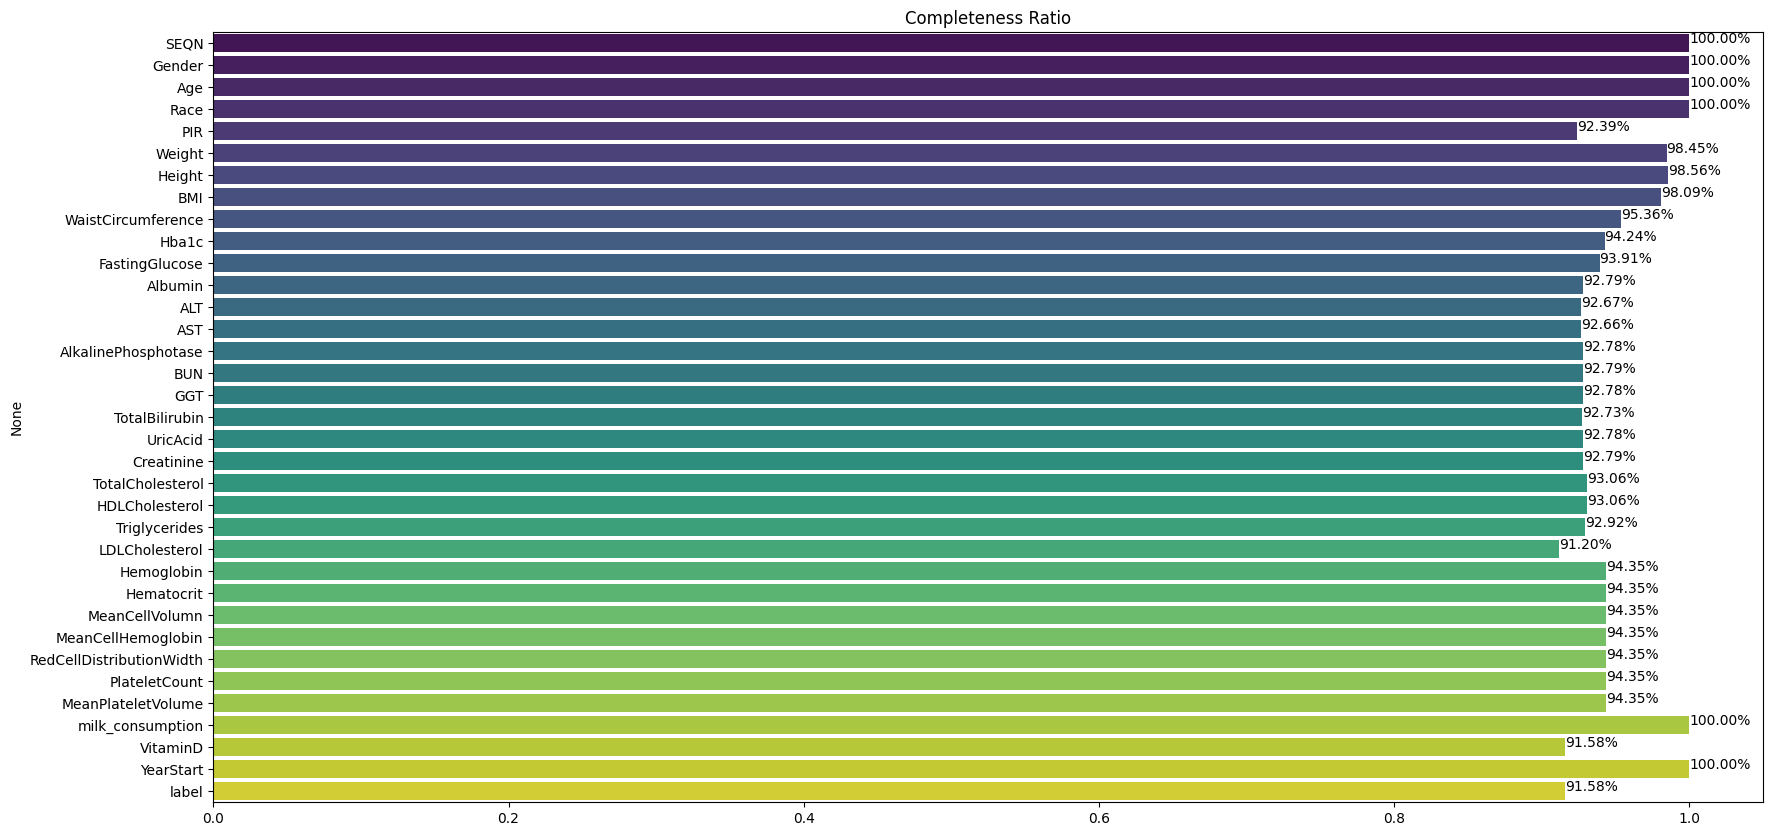

In [31]:
check_missing_ratio(df)

In [32]:
# Drop columns vitamin D and null on column labels
df.dropna(subset=['label'], inplace=True)
df.drop(columns=['VitaminD'], inplace=True)

In [33]:
# PIR null => missing completely randomly => drop
df.dropna(subset=['PIR'], inplace=True)

In [34]:
# Imputation LDL cholesterol
for index, col in enumerate(['LDLCholesterol', 'HDLCholesterol', 'TotalCholesterol']):
    for i, row in df.iterrows():
        if pd.isnull(row[col]):
            TotalCholesterol = row['TotalCholesterol']
            HdlCholesterol = row['HDLCholesterol']
            Triglycerides = row['Triglycerides']
            LdlCholesterol = row['LDLCholesterol']

            if np.isnan(Triglycerides) or Triglycerides > 4.5:
                continue
            if col == 'LDLCholesterol':
                if pd.notna(TotalCholesterol) & pd.notna(HdlCholesterol):
                    df.at[i, 'LDLCholesterol'] = TotalCholesterol - HdlCholesterol - (Triglycerides / 2.2)
            elif col == 'HDLCholesterol':
                if pd.notna(TotalCholesterol) & pd.notna(LdlCholesterol):
                    df.at[i, 'HDLCholesterol'] = TotalCholesterol - LdlCholesterol - (Triglycerides / 2.2)
            elif col == 'TotalCholesterol':
                if pd.notna(LdlCholesterol) & pd.notna(HdlCholesterol):
                    df.at[i, 'TotalCholesterol'] = LdlCholesterol + HdlCholesterol + (Triglycerides / 2.2)

In [35]:
# Fill BMI missing value by formula: BMI = weight (kg) / (height (m))^2
df['BMI'] = df.apply(lambda row: row['Weight'] / ((row['Height'] / 100) ** 2) if pd.isna(row['BMI']) and pd.notna(row['Weight']) and pd.notna(row['Height']) else row['BMI'], axis=1)

### 4. Hanlde Outlier Data

In [ ]:
'''
In medical, The outlier value is so important, so we will not drop it.
'''

### 5. Feature Engineering & Feature Selection

In [28]:
# Group race 0 and 1
df['Race'] = df['Race'].apply(lambda x: 1 if x == 2 else x)

# One hot encoding for race column
df = pd.get_dummies(df, columns=['Race'], prefix='Race')

In [ ]:
# diabetes assign:
def is_diabetes(row):
    if row >= 6.5:
        return 2
    elif row >= 5.7:
        return 1
    else:
        return 0
df['Hba1c'] = df['Hba1c'].apply(is_diabetes)

In [19]:
df.columns

Index(['SEQN', 'Gender', 'Age', 'Race', 'PIR', 'Weight', 'Height', 'BMI',
       'WaistCircumference', 'Hba1c', 'FastingGlucose', 'Albumin', 'ALT',
       'AST', 'AlkalinePhosphotase', 'BUN', 'GGT', 'TotalBilirubin',
       'UricAcid', 'Creatinine', 'TotalCholesterol', 'HDLCholesterol',
       'Triglycerides', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', 'milk_consumption', 'YearStart',
       'label'],
      dtype='object')

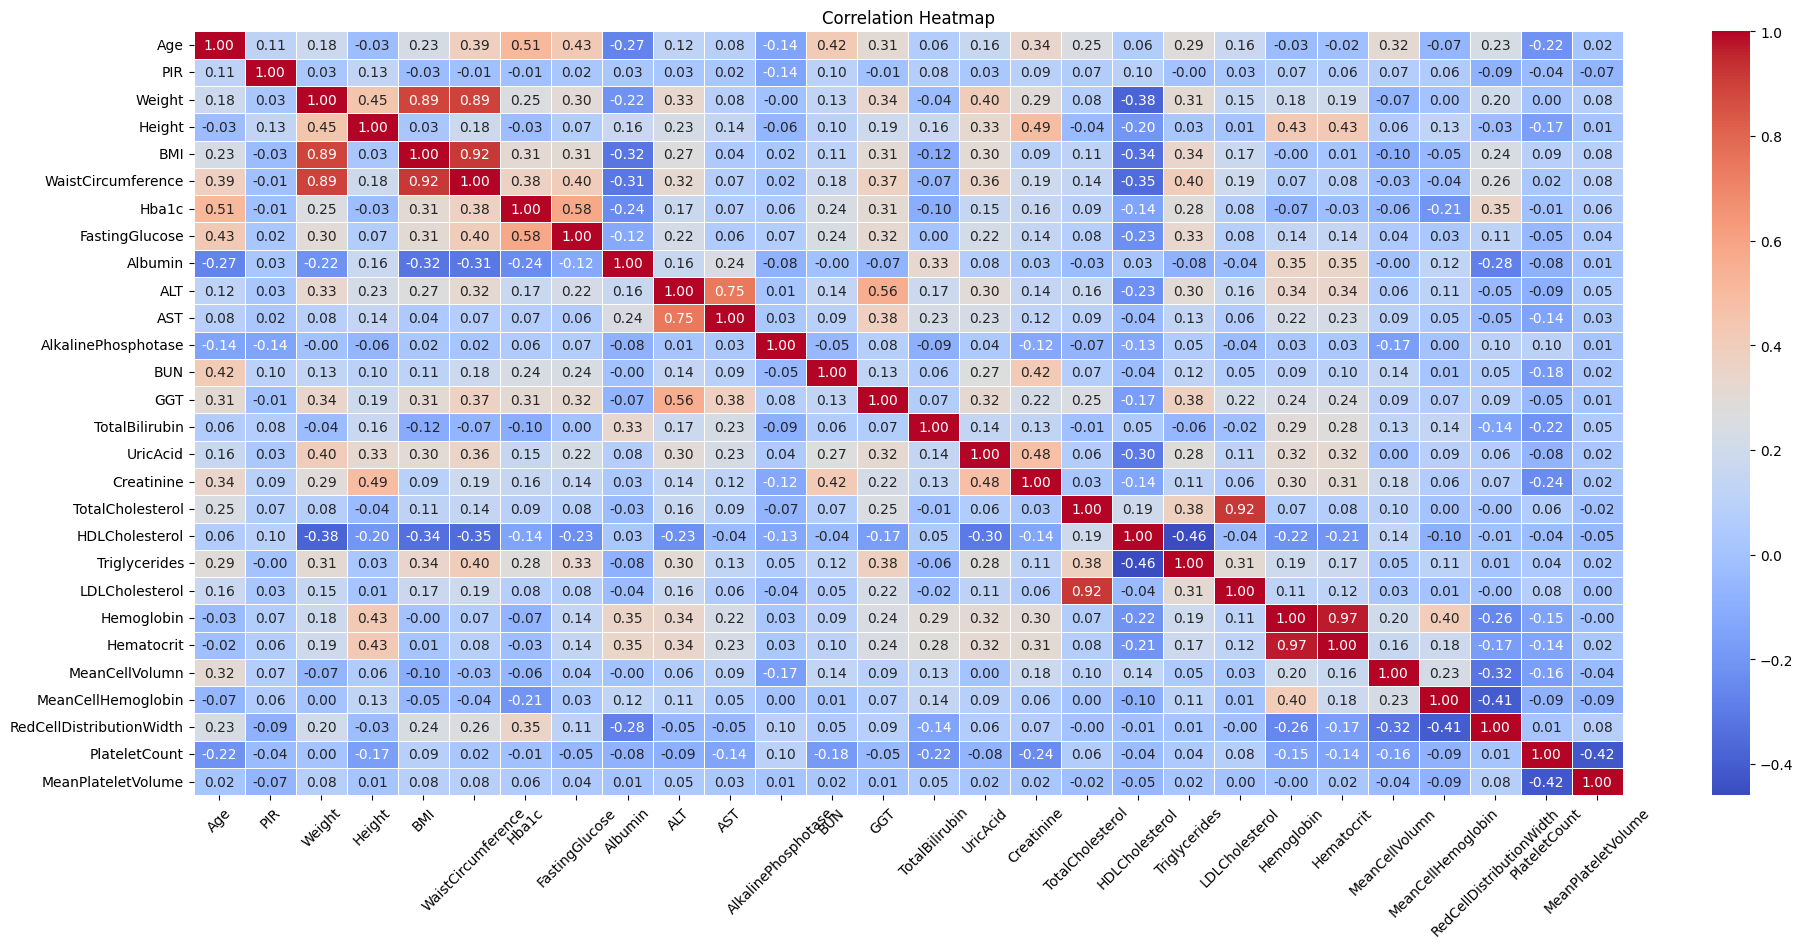

In [20]:
# Draw heat map to visualize correlation
df_corr = df.copy()
df_corr.drop(columns=[
    "SEQN", "Gender", "milk_consumption",
    "Race", "label", "YearStart"
], inplace=True)

# Check consistency between columns with spearman correlation
correlation_matrix = df_corr.corr(method = "spearman")

plt.figure(figsize=(20, 10))  # Kích thước biểu đồ
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [29]:
# Drop columns that has high correlation
list_columns_drop = [
    "Weight", "Height",
    "WaistCircumference", "TotalCholesterol",
    "Hemoglobin", "ALT"
]

df = df.drop(columns=list_columns_drop)

In [36]:
# Drop remaining missing value
df = df.dropna()

c:\Users\duyp6\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:30:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


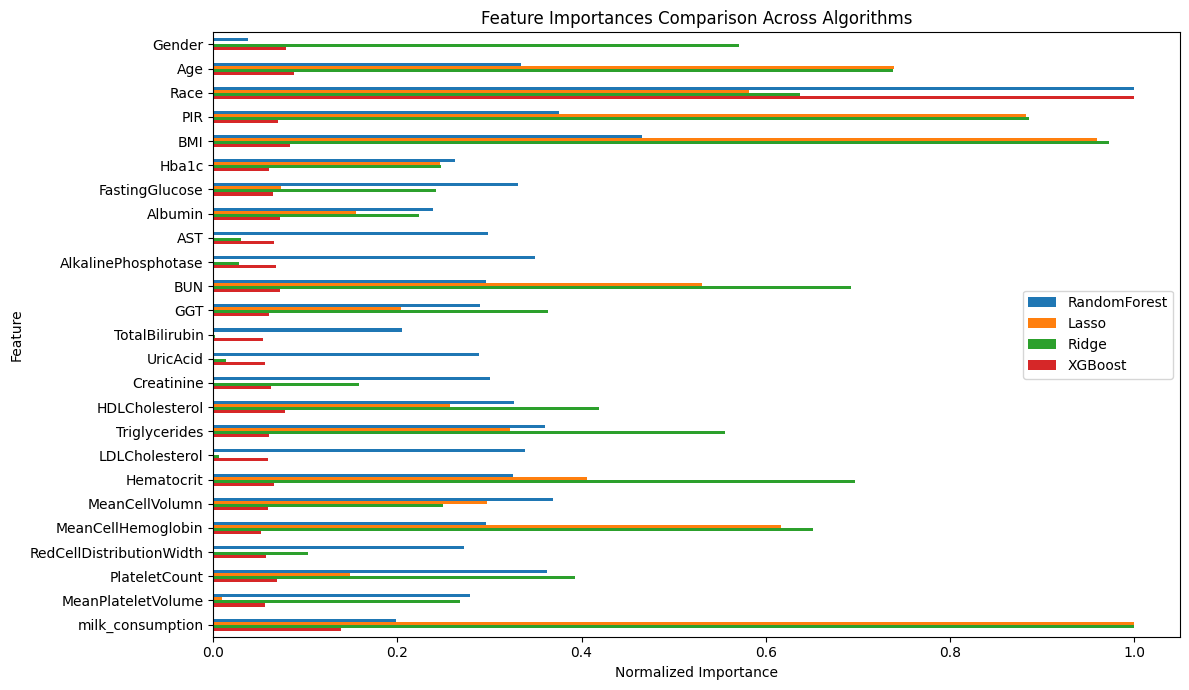

                     Feature  RandomForest     Lasso     Ridge   XGBoost
2                       Race      1.000000  0.581511  0.637404  1.000000
4                        BMI      0.465974  0.959635  0.972510  0.083626
3                        PIR      0.375413  0.882346  0.885474  0.069770
19            MeanCellVolumn      0.369263  0.297522  0.250042  0.059224
22             PlateletCount      0.362795  0.148656  0.392838  0.069045
16             Triglycerides      0.360518  0.321779  0.556202  0.060805
9        AlkalinePhosphotase      0.349045  0.000000  0.027898  0.068342
17            LDLCholesterol      0.338292  0.000000  0.006473  0.059500
1                        Age      0.334425  0.739824  0.738377  0.087362
6             FastingGlucose      0.331189  0.073558  0.241684  0.065149
15            HDLCholesterol      0.326892  0.256875  0.418845  0.077705
18                Hematocrit      0.325067  0.405903  0.697217  0.065691
14                Creatinine      0.300883  0.00000

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, Ridge
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

list_columns_unused = ['YearStart', 'SEQN']
list_columns_categorical = ['Gender', 'milk_consumption', "Race"]

X = df.drop(columns=['label'] + list_columns_unused)
y = df['label']

numerical_cols = [c for c in X.columns if c not in list_columns_categorical]
categorical_cols = list_columns_categorical

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])

feature_names = X.columns

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_importance = rf.feature_importances_

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
lasso_importance = np.abs(lasso.coef_)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_importance = np.abs(ridge.coef_)

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_importance = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RandomForest': rf_importance,
    'Lasso': lasso_importance,
    'Ridge': ridge_importance,
    'XGBoost': xgb_importance
})

for col in ['RandomForest', 'Lasso', 'Ridge', 'XGBoost']:
    importance_df[col] = importance_df[col] / importance_df[col].max()

top_features = importance_df.sort_values(by='RandomForest', ascending=False).head(30)['Feature']
importance_df_top = importance_df[importance_df['Feature'].isin(top_features)]

importance_df_top.set_index('Feature').plot(kind='barh', figsize=(12, 7))
plt.title("Feature Importances Comparison Across Algorithms")
plt.xlabel("Normalized Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df.sort_values(by='RandomForest', ascending=False).head(30))


### 6. Handle Normalization Data

In [ ]:
# Integration when training model using standard scaler for numerical and one hot encoding for categorical

### 7. Save data 

In [ ]:
df.to_csv(r'data/processed/processed_train_data.csv', index=False)
df.to_csv(r'data/processed/processed_test_data.csv', index=False)